# Electricity Distribution Losses in Uganda: A Spatial and Temporal Analysis
**Author:** Tony Blair Ochieng | UTAMU MSc AI & Data Science | Jan26/MAIDS/0077U  
**Date:** April 2025  
**Course:** Kujenga Final Project  
**Data Sources:** ERA Uganda, energydata.info (GIZ), World Bank

---

## 1. Research Question

**What spatial and temporal factors explain electricity distribution losses in Uganda,
 and can we predict which regions and companies are most at risk of high losses?**

Uganda's electricity distribution losses stand at **17.1%** as of mid-2025 (ERA, 2025), down from over 30% at
 sector liberalisation in 2001. While progress has been made, losses remain nearly three times the global best-practice
 target of ~6%. Every percentage point of loss represents gigawatt-hours of electricity generated but never billed —
 a direct financial and economic cost.

This project uses ERA regulatory data and Uganda Energy Sector GIS data to:
1. Describe the temporal trend in distribution losses nationally and by company (2005–2024)
2. Test whether urban vs. rural networks have significantly different loss rates (t-test)
3. Model the relationship between network length, customer density, and loss % (regression)
4. Map loss risk spatially across Uganda's regions (GIS)
5. Forecast the loss trajectory to 2030 under current trends


## 2. Data Description

| Dataset | Source | Format | Key Variables |
|---|---|---|---|
| Distribution energy purchases, sales & losses | ERA Uganda | `.xlsm` | Year, Company, GWh purchased/sold, Loss % |
| Distribution network length | ERA Uganda | `.xlsm` | Year, Company, MV/LV line km |
| Customer growth | ERA Uganda | `.xlsm` | Year, Company, Customer count |
| Transmission purchases, sales & losses | ERA Uganda | `.xlsm` | Year, GWh, Transmission loss % |
| Distribution lines (GIS) | energydata.info / GIZ | `.geojson` | Line geometry, voltage, status |
| Substations (GIS) | energydata.info / GIZ | `.geojson` | Point geometry, substation type |
| Uganda admin boundaries | GADM / geoBoundaries | `.geojson` | District polygons |

### 📥 How to obtain the data

**ERA Excel files** (download directly in your browser):
```
Distribution losses DB:  https://www.era.go.ug/media/2026/01/Distribution_Database_Q3_2025-Updated.xlsm
Network length DB:       https://www.era.go.ug/media/2026/04/Distribution_Statistics_Q4_2025_20260402.xlsm
Detailed statistics:     https://www.era.go.ug/media/2024/11/Detailed-Statistics.xlsx
```
Saved them into the `data/raw/` folder.

**GIS files** (free download, CC-BY 4.0):
```
Distribution lines:  https://energydata.info/dataset/distribution-lines-2023
Transmission lines:  https://energydata.info/dataset/uganda-electricity-transmission-network-2017
Admin boundaries:    https://gadm.org/download_country.html  →  Uganda → GeoJSON
```
Saved GeoJSONs into the `data/gis/` folder.


## 3. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import folium
from scipy import stats
from scipy.stats import pearsonr, ttest_ind
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
UGANDA_GREEN = '#2E7D32'
UGANDA_YELLOW = '#F9A825'
print('Imports OK')


Imports OK


In [16]:
import os
print('Current working directory:', os.getcwd())
os.chdir('/Users/rtv-lpt-495/Desktop/ugelectricity')
print('Updated working directory:', os.getcwd())

Current working directory: /Users/rtv-lpt-495/Desktop/ugelectricity
Updated working directory: /Users/rtv-lpt-495/Desktop/ugelectricity


## 4. Data Loading & Inspection

In [17]:
# ── LOAD ERA DISTRIBUTION DATABASE ──────────────────────────────────────────
# The ERA xlsm file has multiple sheets. Inspect with:
#   xl = pd.ExcelFile('data/raw/Distribution_Database_Q3_2025-Updated.xlsm')
#   print(xl.sheet_names)
# Then load the relevant sheets:

ERA_DIST_FILE = 'data/raw/Distribution_Database_Q3_2025-Updated.xlsm'
ERA_NETWORK_FILE = 'data/raw/Distribution_Statistics_Q4_2025_20260402.xlsm'
ERA_DETAIL_FILE = 'data/raw/Detailed-Statistics.xlsx'

# ── Step 1: Preview sheet names (run this first, then adjust sheet names below)
xl_dist = pd.ExcelFile(ERA_DIST_FILE, engine='openpyxl')
print('Distribution DB sheets:', xl_dist.sheet_names)

xl_net = pd.ExcelFile(ERA_NETWORK_FILE, engine='openpyxl')
print('Network length sheets:', xl_net.sheet_names)


Distribution DB sheets: ['Distrib Utility Report (Quarte)', 'Distribution Dashboard', 'Umm', 'Sheet1', 'Sheet2', 'Energy_Purchased_kWh', 'Energy Sales_kWh', 'Number of Employees', 'Number of Customers ', 'Network Length (Kms)', 'O&M_ShsMillions ', 'Transformer_and_meters', 'Other notes', 'Energy Purchased', 'Energy Sales', 'Customers', 'Network_Length', 'a', 'Notes', 'Distribution', 'REFERENCES']
Network length sheets: ['Distrib Utility Report (Quarte)', 'Distribution Dashboard', 'Umm', 'Sheet1', 'Sheet2', 'Energy_Purchased_kWh', 'Energy Sales_kWh', 'Number of Employees', 'Number of Customers ', 'Network Length (Kms)', 'O&M_ShsMillions ', 'Transformer_and_meters', 'Other notes', 'Energy Purchased', 'Energy Sales', 'Customers', 'Network_Length', 'a', 'Notes', 'Distribution', 'REFERENCES']


In [18]:
# ── PREVIEW KEY SHEETS ────────────────────────────────────────────────────
ERA_FILE = 'data/raw/Distribution_Database_Q3_2025-Updated.xlsm'

sheets_to_check = [
    'Energy_Purchased_kWh',
    'Energy Sales_kWh',
    'Network Length (Kms)',
    'Network_Length',
    'Number of Customers ',
    'Customers',
    'Distribution',
]

for sheet in sheets_to_check:
    try:
        df = pd.read_excel(ERA_FILE, sheet_name=sheet, engine='openpyxl', nrows=8)
        print(f"\n{'═'*60}")
        print(f"Sheet: '{sheet}'  →  shape preview (8 rows × {df.shape[1]} cols)")
        print(f"{'═'*60}")
        print(df.to_string())
    except Exception as e:
        print(f"\n[SKIP] '{sheet}': {e}")


════════════════════════════════════════════════════════════
Sheet: 'Energy_Purchased_kWh'  →  shape preview (8 rows × 22 cols)
════════════════════════════════════════════════════════════
   Unnamed: 0 Unnamed: 1 Unnamed: 2     Unnamed: 3             Unnamed: 4        Unnamed: 5        Unnamed: 6                                       Unnamed: 7  Unnamed: 8  Unnamed: 9     Unnamed: 10     Unnamed: 11 Unnamed: 12     Unnamed: 13      Unnamed: 14 Unnamed: 15 Unnamed: 16 Unnamed: 17     Unnamed: 18          Unnamed: 19                              Unnamed: 20                         Unnamed: 21
0         NaN     PERIOD        NaN  UEDCL OVERALL  UMEME UGANDA LIMITED                NaN               NaN  UGANDA ELECTRICITY DISTRIBUTION COMPANY LIMITED         NaN         NaN             NaN             NaN         NaN             NaN              NaN         NaN         NaN         NaN             NaN  KABALEGA HYDROMAX**  WESTNILE RURAL ELECTRIFICATION COMPANY*  KALANGALA INFRASTRUCTURE 

In [19]:
# ── Step 2: Load the losses sheet (adjust sheet name after previewing above)
# ERA typically structures: one row per company per year
# Common sheet names: 'Distribution Losses', 'Energy Losses', 'Dist Losses'

LOSSES_SHEET = 'Distribution'
NETWORK_SHEET = 'Network_Length'

df_losses_raw = pd.read_excel(ERA_DIST_FILE, sheet_name=LOSSES_SHEET, engine='openpyxl')
df_network_raw = pd.read_excel(ERA_NETWORK_FILE, sheet_name=NETWORK_SHEET, engine='openpyxl')

print('Losses sheet:', LOSSES_SHEET, 'shape:', df_losses_raw.shape)
print('Network sheet:', NETWORK_SHEET, 'shape:', df_network_raw.shape)
df_losses_raw.head(10)


Losses sheet: Distribution shape: (613, 155)
Network sheet: Network_Length shape: (1704, 5)


,Years,Quarters,Period,ElectricitySector,DivideName,Utility,Abbreviation,Type,code,REC_ID,...,Poles,- Borrowings,- Finance leases,- Lease rental expenses,Interest income,Dividend income,Wheeling losses%,Technical loss estimates%,Commercial loss estimates%,Unnamed: 154
0,2017,Q4,2017Q4,Distribution,Local,Pader Abim Community Multipurpose Electric Co-...,PACMECS,PACMECS,D9,2017Q4D9,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0566,0.16,0.01,NaN
1,2017,Q4,2017Q4,Distribution,Local,UEDCL,UEDCL,UEDCL,D13,2017Q4D13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,Q4,2017Q4,Distribution,Local,Southern West Service Territory (SWST),SWST,UEDCL,D7,2017Q4D7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,Q4,2017Q4,Distribution,Local,Southern Service Territory (SST),SST,UEDCL,D6,2017Q4D6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017,Q4,2017Q4,Distribution,Local,North Western Service Territory (NWST),NWST,UEDCL,D8,2017Q4D8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017,Q4,2017Q4,Distribution,Local,North North West Service Territory (NNWST),NNWST,UEDCL,D5,2017Q4D5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017,Q4,2017Q4,Distribution,Local,North East Service Territory (NEST),NEST,UEDCL,D4,2017Q4D4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2017,Q4,2017Q4,Distribution,Local,Mid West Service Territory (MWST),MWST,UEDCL,D3,2017Q4D3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2017,Q4,2017Q4,Distribution,Local,Kilembe Investment Limited,KIL,KIL,D12,2017Q4D12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2017,Q4,2017Q4,Distribution,Local,Eastern Service Territory (EST),EST,UEDCL,D2,2017Q4D2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Cleaning

In [20]:
# ── STANDARDISE COLUMNS ──────────────────────────────────────────────────────
# The Distribution sheet contains quarterly utility data with explicit columns.
# We derive annual distribution loss rates from energy purchased vs sales.

df_losses = df_losses_raw.copy()
df_losses = df_losses.dropna(subset=['Years', 'Utility', 'Type', 'Total_purchased', 'Total_sales_KWh']).copy()
df_losses = df_losses[df_losses['Years'].apply(lambda x: isinstance(x, (int, float)))].copy()
df_losses['year'] = df_losses['Years'].astype(int)
df_losses['company'] = df_losses['Type'].astype(str).str.strip()

# Keep only utility-level totals and exclude service territory breakdowns to avoid double-counting.
df_losses = df_losses[~df_losses['Utility'].str.contains('Service Territory', na=False)]

df_losses['loss_pct'] = (
    (df_losses['Total_purchased'] - df_losses['Total_sales_KWh'])
    / df_losses['Total_purchased'] * 100
)
df_losses = df_losses.replace([np.inf, -np.inf], np.nan)
df_losses = df_losses.dropna(subset=['loss_pct'])
df_losses = df_losses[df_losses['loss_pct'].between(0, 60)]

urban_companies   = ['Umeme', 'Umeme Limited', 'UMEME']
rural_companies   = ['WENRECo', 'BECS', 'KRECS', 'PACMECS', 'KIL', 'Hydromax', 'KIS']
periurban_companies = ['UEDCL']

def classify_company(name):
    name = str(name)
    if any(u in name for u in urban_companies):    return 'urban'
    if any(r in name for r in rural_companies):    return 'rural'
    if any(p in name for p in periurban_companies): return 'peri-urban'
    return 'other'

df_losses['company_type'] = df_losses['company'].apply(classify_company)

df_losses = df_losses.groupby(['company', 'year', 'company_type'], as_index=False)['loss_pct'].mean()

print('Final dataset shape:', df_losses.shape)
print('Years:', df_losses.year.min(), '–', df_losses.year.max())
print('Companies:', df_losses.company.nunique())
df_losses.sample(5)


Final dataset shape: (60, 4)
Years: 2008 – 2022
Companies: 6


,company,year,company_type,loss_pct
39,PACMECS,2019,rural,19.470862
10,KIL,2010,rural,28.136036
17,KIL,2017,rural,21.778323
58,Umeme,2021,urban,18.004636
51,Umeme,2014,urban,21.469862


In [21]:
# ── FILTER OUTLIERS (IQR method on loss_pct) ─────────────────────────────
Q1 = df_losses['loss_pct'].quantile(0.25)
Q3 = df_losses['loss_pct'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_losses[(df_losses['loss_pct'] < lower) | (df_losses['loss_pct'] > upper)]
print(f'Potential outliers (outside [{lower:.1f}%, {upper:.1f}%]): {len(outliers)} rows')
print(outliers[['company','year','loss_pct']])
# Keep them unless they are clearly data entry errors (> 60% or < 0%)
df_losses = df_losses[(df_losses['loss_pct'] > 0) & (df_losses['loss_pct'] < 60)]
print('Rows after sanity filter:', len(df_losses))

Potential outliers (outside [1.5%, 43.3%]): 4 rows
   company  year   loss_pct
9     BECS  2020  57.967845
11     KIL  2011  52.228001
12     KIL  2012  51.181883
22     KIL  2022  45.360725
Rows after sanity filter: 60


## 6. Exploratory Data Analysis (EDA)

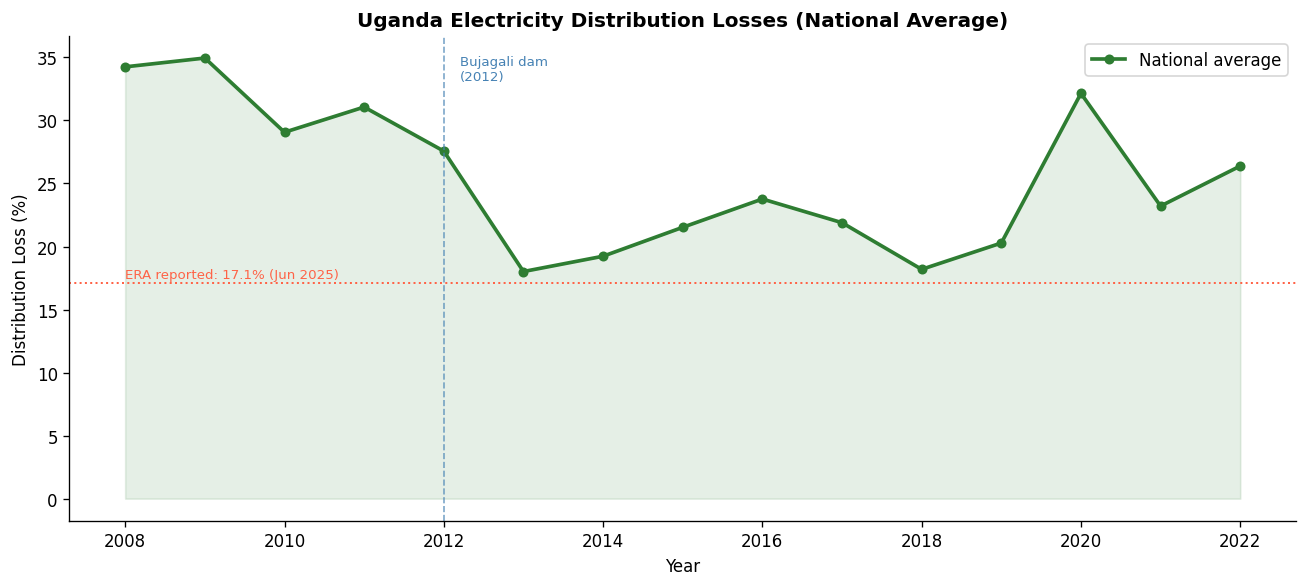

In [22]:
# ── PLOT 1: National distribution loss trend (2005–2024) ─────────────────
national = df_losses.groupby('year')['loss_pct'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(national['year'], national['loss_pct'], alpha=0.12, color=UGANDA_GREEN)
ax.plot(national['year'], national['loss_pct'], '-o', color=UGANDA_GREEN,
        linewidth=2.2, markersize=5, label='National average')

# Annotation: Bujagali dam completion
ax.axvline(2012, color='steelblue', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2012.2, national['loss_pct'].max() * 0.95, 'Bujagali dam\n(2012)', fontsize=8, color='steelblue')

# ERA 2025 reported figure
ax.axhline(17.1, color='tomato', linestyle=':', linewidth=1.2)
ax.text(national['year'].min(), 17.5, 'ERA reported: 17.1% (Jun 2025)', fontsize=8, color='tomato')

ax.set_xlabel('Year')
ax.set_ylabel('Distribution Loss (%)')
ax.set_title('Uganda Electricity Distribution Losses (National Average)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig1_national_loss_trend.png', dpi=150)
plt.show()

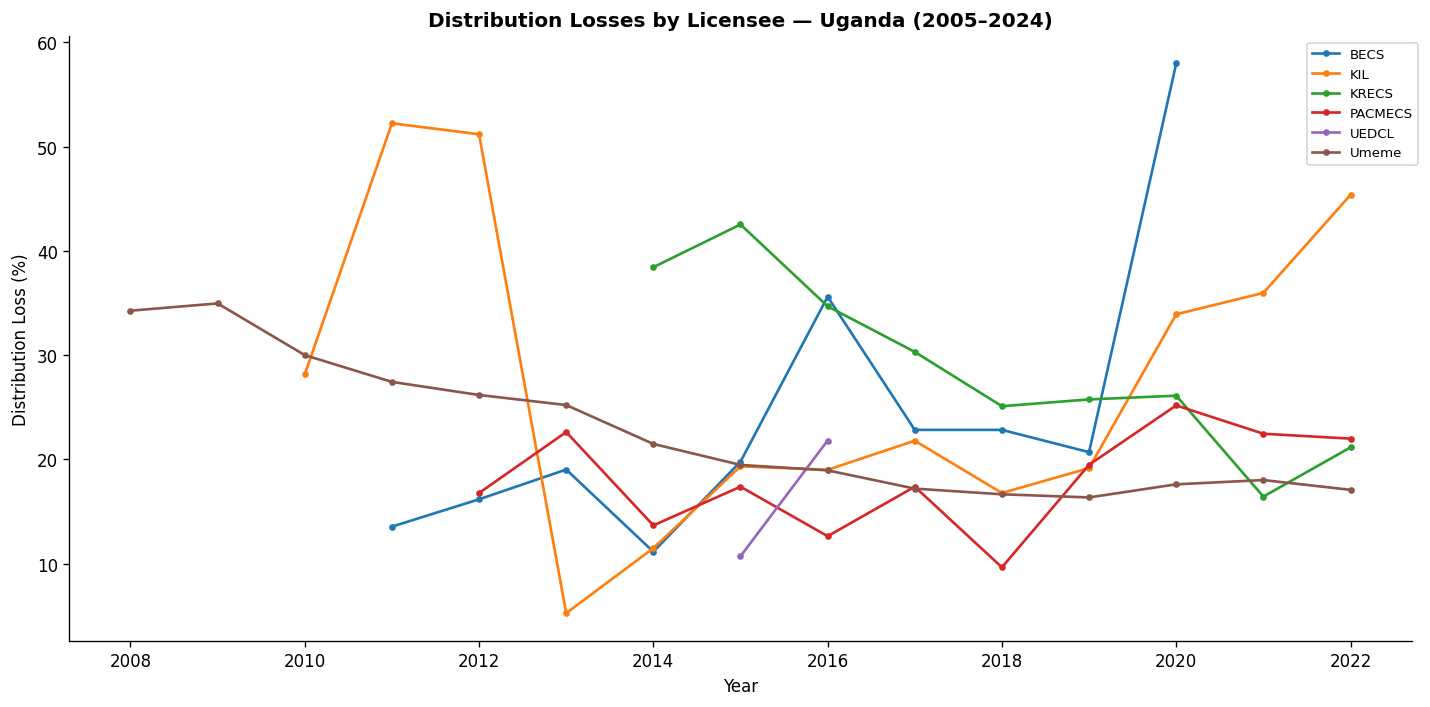

In [23]:
# ── PLOT 2: Loss % by company over time ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('tab10', n_colors=df_losses['company'].nunique())

for i, (company, grp) in enumerate(df_losses.groupby('company')):
    grp_sorted = grp.sort_values('year')
    ax.plot(grp_sorted['year'], grp_sorted['loss_pct'],
            marker='o', markersize=3, linewidth=1.6, label=company, color=palette[i])

ax.set_xlabel('Year')
ax.set_ylabel('Distribution Loss (%)')
ax.set_title('Distribution Losses by Licensee — Uganda (2005–2024)', fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.savefig('data/fig2_losses_by_company.png', dpi=150)
plt.show()

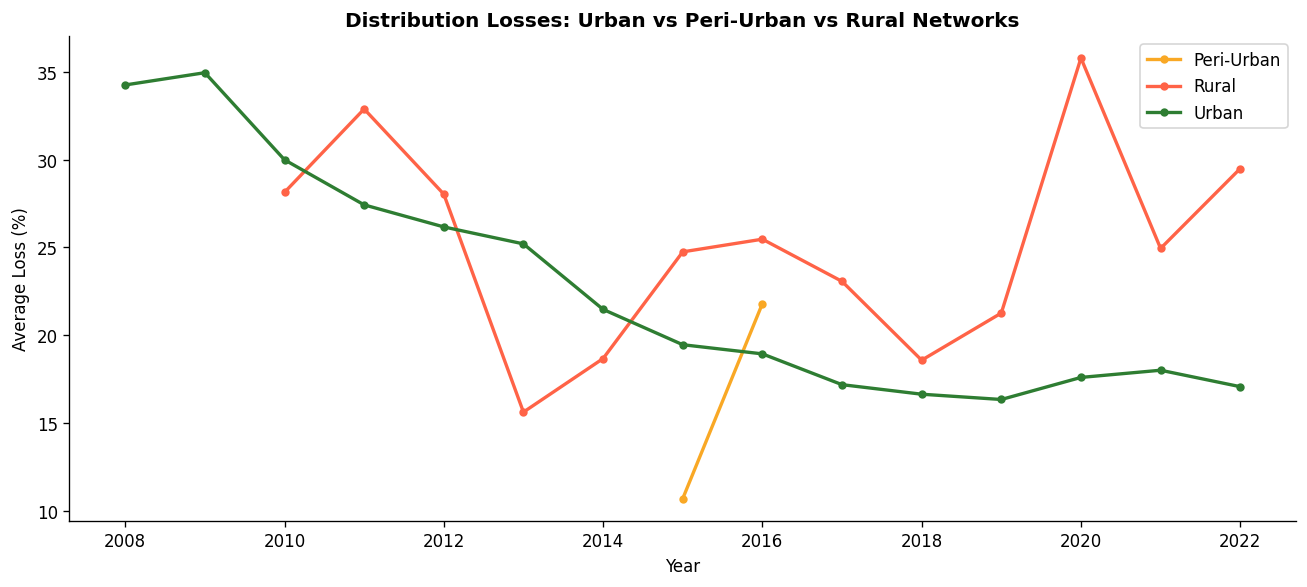

In [24]:
# ── PLOT 3: Urban vs rural average losses ────────────────────────────────
type_summary = df_losses.groupby(['year', 'company_type'])['loss_pct'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
colors = {'urban': UGANDA_GREEN, 'peri-urban': UGANDA_YELLOW, 'rural': 'tomato'}
for ctype, grp in type_summary.groupby('company_type'):
    ax.plot(grp['year'], grp['loss_pct'], '-o', markersize=4,
            color=colors.get(ctype, 'gray'), linewidth=2, label=ctype.title())

ax.set_xlabel('Year')
ax.set_ylabel('Average Loss (%)')
ax.set_title('Distribution Losses: Urban vs Peri-Urban vs Rural Networks', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig3_urban_rural_losses.png', dpi=150)
plt.show()

## 7. Statistical Analysis — t-test: Urban vs Rural Losses

In [25]:
# ── Welch's t-test: Are rural network losses significantly higher than urban?

urban_losses = df_losses[df_losses['company_type'] == 'urban']['loss_pct'].dropna()
rural_losses = df_losses[df_losses['company_type'] == 'rural']['loss_pct'].dropna()

t_stat, p_value = ttest_ind(rural_losses, urban_losses, equal_var=False)

print('═' * 55)
print('Welch\'s t-test: Rural vs Urban Distribution Losses')
print('═' * 55)
print(f'  Urban mean loss:  {urban_losses.mean():.2f}%  (n={len(urban_losses)})')
print(f'  Rural mean loss:  {rural_losses.mean():.2f}%  (n={len(rural_losses)})')
print(f'  Difference:      +{rural_losses.mean() - urban_losses.mean():.2f} pp')
print(f'  t-statistic:      {t_stat:.3f}')
print(f'  p-value:          {p_value:.4f}')
print(f'  Result:           {"Significant (p < 0.05)" if p_value < 0.05 else "Not significant"}')
print()

# ── t-test 2: Pre-2012 vs Post-2012 (Bujagali dam effect)
pre_bujagali  = df_losses[df_losses['year'] < 2012]['loss_pct'].dropna()
post_bujagali = df_losses[df_losses['year'] >= 2012]['loss_pct'].dropna()

t2, p2 = ttest_ind(post_bujagali, pre_bujagali, equal_var=False)
print('═' * 55)
print('Welch\'s t-test: Pre vs Post Bujagali Dam (2012)')
print('═' * 55)
print(f'  Pre-2012 mean:   {pre_bujagali.mean():.2f}%')
print(f'  Post-2012 mean:  {post_bujagali.mean():.2f}%')
print(f'  t-statistic:     {t2:.3f}')
print(f'  p-value:         {p2:.4f}')
print(f'  Result:          {"Significant (p < 0.05)" if p2 < 0.05 else "Not significant"}')

═══════════════════════════════════════════════════════
Welch's t-test: Rural vs Urban Distribution Losses
═══════════════════════════════════════════════════════
  Urban mean loss:  22.71%  (n=15)
  Rural mean loss:  24.62%  (n=43)
  Difference:      +1.90 pp
  t-statistic:      0.770
  p-value:          0.4451
  Result:           Not significant

═══════════════════════════════════════════════════════
Welch's t-test: Pre vs Post Bujagali Dam (2012)
═══════════════════════════════════════════════════════
  Pre-2012 mean:   31.50%
  Post-2012 mean:  22.85%
  t-statistic:     -1.884
  p-value:         0.0998
  Result:          Not significant


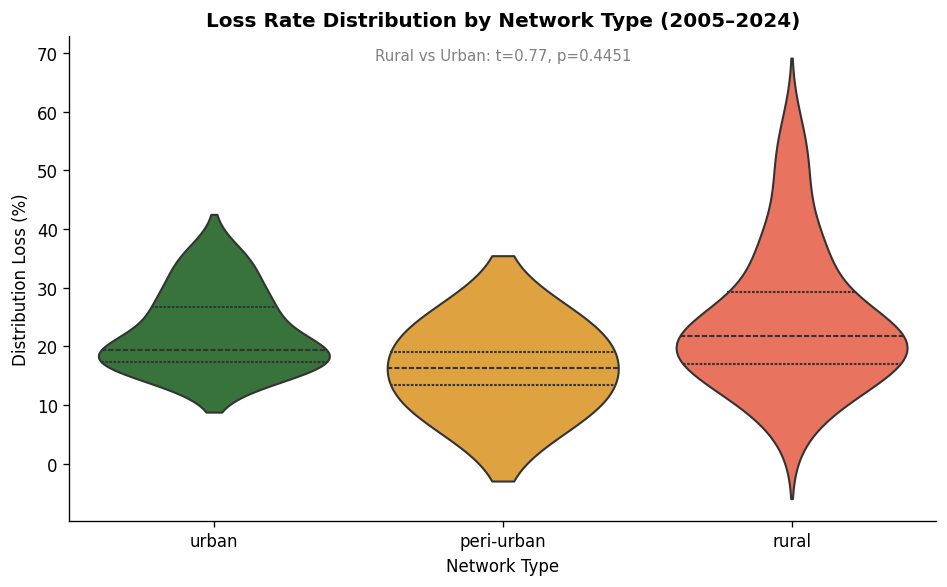

In [26]:
# ── Violin plot: distribution of loss % by company type ──────────────────
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = df_losses[df_losses['company_type'].isin(['urban', 'peri-urban', 'rural'])]
order = ['urban', 'peri-urban', 'rural']
pal = {'urban': UGANDA_GREEN, 'peri-urban': UGANDA_YELLOW, 'rural': 'tomato'}
sns.violinplot(data=plot_data, x='company_type', y='loss_pct',
               order=order, palette=pal, ax=ax, inner='quartile')

ax.set_xlabel('Network Type')
ax.set_ylabel('Distribution Loss (%)')
ax.set_title('Loss Rate Distribution by Network Type (2005–2024)', fontsize=12, fontweight='bold')
ax.text(0.5, 0.95, f'Rural vs Urban: t={t_stat:.2f}, p={p_value:.4f}',
        ha='center', transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('data/fig4_violin_loss_by_type.png', dpi=150)
plt.show()

## 8. Regression Analysis — Predicting Distribution Losses

In [27]:
# ── Merge losses with network length and customer data ────────────────────
df_network = df_network_raw.copy()
df_network = df_network.dropna(subset=['Utility', 'Year', 'Length']).copy()
df_network = df_network[df_network['Year'].apply(lambda x: isinstance(x, (int, float)))].copy()
df_network['year'] = df_network['Year'].astype(int)
df_network['company'] = df_network['Utility'].astype(str).str.strip()
df_network['network_km'] = pd.to_numeric(df_network['Length'], errors='coerce')
df_network = df_network.dropna(subset=['network_km'])
df_network = df_network.groupby(['company', 'year'], as_index=False)['network_km'].max()

# Merge on company + year
df_model = df_losses.merge(df_network[['company','year','network_km']], on=['company','year'], how='inner')

# Feature engineering
df_model['log_network_km'] = np.log1p(df_model['network_km'])
df_model['is_rural'] = (df_model['company_type'] == 'rural').astype(int)
df_model['year_scaled'] = df_model['year'] - df_model['year'].min()

print('Model dataset shape:', df_model.shape)
df_model.describe()


Model dataset shape: (45, 8)


,year,loss_pct,network_km,log_network_km,is_rural,year_scaled
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,2016.511111,24.243223,362.031156,5.431400,0.955556,6.511111
std,3.279566,11.813559,280.431671,1.381765,0.208409,3.279566
min,2010.000000,5.234022,0.000000,0.000000,0.000000,0.000000
25%,2014.000000,16.762423,147.000000,4.997212,1.000000,4.000000
50%,2016.000000,21.778323,290.000000,5.673323,1.000000,6.000000
75%,2019.000000,28.136036,565.393000,6.339288,1.000000,9.000000
max,2022.000000,57.967845,1195.000000,7.086738,1.000000,12.000000


Simple regression: Year → Loss%
  Slope:  -0.604 pp/year (negative = improving)
  R²:     0.216
  MAE:    4.12 pp


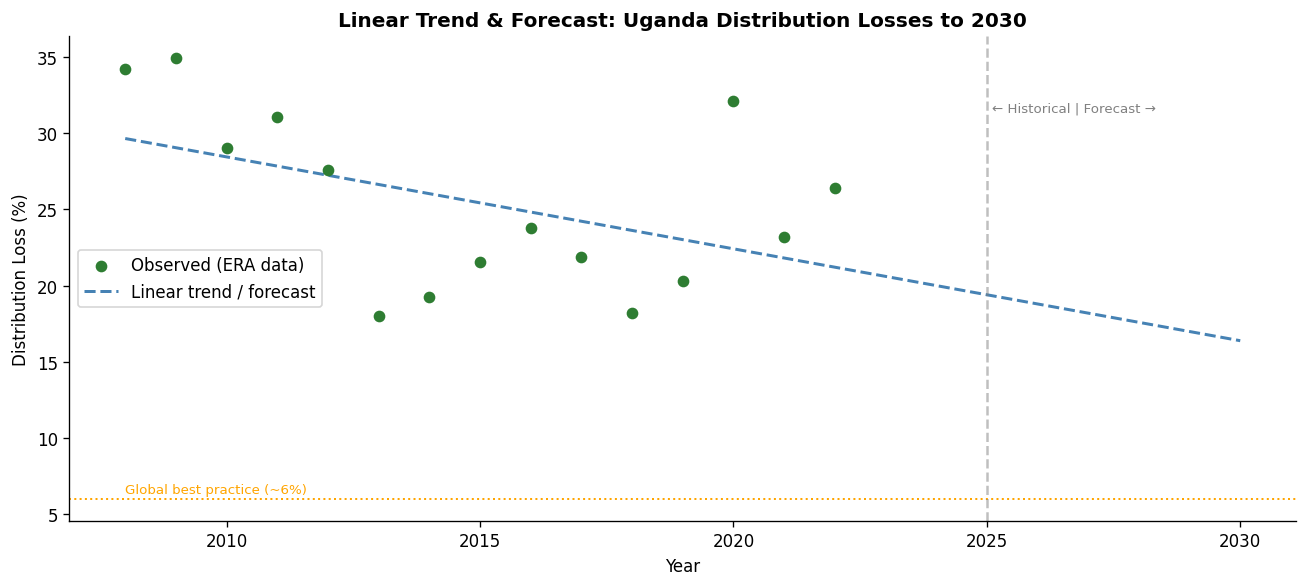

In [28]:
# ── Simple linear regression: Year → National average loss % ─────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

nat_annual = df_losses.groupby('year')['loss_pct'].mean().reset_index()
X_yr = nat_annual[['year']].values
y_yr = nat_annual['loss_pct'].values

lr_year = LinearRegression()
lr_year.fit(X_yr, y_yr)
y_pred_yr = lr_year.predict(X_yr)

print('Simple regression: Year → Loss%')
print(f'  Slope:  {lr_year.coef_[0]:.3f} pp/year (negative = improving)')
print(f'  R²:     {r2_score(y_yr, y_pred_yr):.3f}')
print(f'  MAE:    {mean_absolute_error(y_yr, y_pred_yr):.2f} pp')

# ── Forecast to 2030 ──────────────────────────────────────────────────────
years_future = np.array(range(nat_annual['year'].min(), 2031)).reshape(-1, 1)
forecast = lr_year.predict(years_future)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(nat_annual['year'], y_yr, color=UGANDA_GREEN, zorder=5, label='Observed (ERA data)')
ax.plot(years_future, forecast, '--', color='steelblue', linewidth=1.8, label='Linear trend / forecast')

# 6% target line (global best practice)
ax.axhline(6, color='orange', linestyle=':', linewidth=1.2)
ax.text(nat_annual['year'].min(), 6.4, 'Global best practice (~6%)', fontsize=8, color='orange')

ax.axvline(2025, color='gray', linestyle='--', alpha=0.5)
ax.text(2025.1, y_yr.max() * 0.9, '← Historical | Forecast →', fontsize=8, color='gray')

ax.set_xlabel('Year')
ax.set_ylabel('Distribution Loss (%)')
ax.set_title('Linear Trend & Forecast: Uganda Distribution Losses to 2030', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig5_regression_forecast.png', dpi=150)
plt.show()

Multiple regression: year + network_km + is_rural → Loss%
  year_scaled         : +2.232
  log_network_km      : -6.292
  is_rural            : -2.092
  intercept:           45.881
  R²:  0.281
  MAE: 7.50 pp


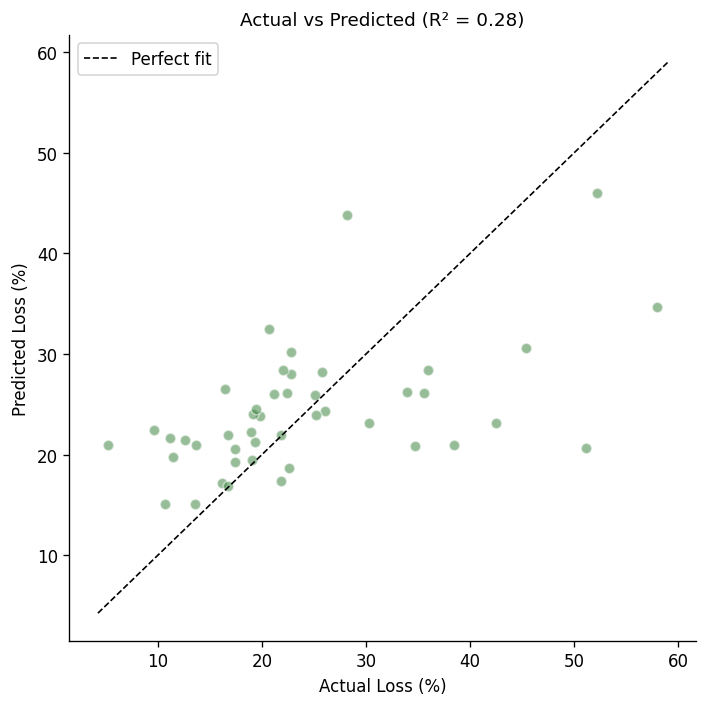

In [29]:
# ── Multiple regression: Network length + rural flag → Loss % ─────────────
features = ['year_scaled', 'log_network_km', 'is_rural']
df_reg = df_model[features + ['loss_pct']].dropna()

X = df_reg[features].values
y = df_reg['loss_pct'].values

lr_multi = LinearRegression()
lr_multi.fit(X, y)
y_pred_m = lr_multi.predict(X)

print('Multiple regression: year + network_km + is_rural → Loss%')
for fname, coef in zip(features, lr_multi.coef_):
    print(f'  {fname:20s}: {coef:+.3f}')
print(f'  intercept:           {lr_multi.intercept_:.3f}')
print(f'  R²:  {r2_score(y, y_pred_m):.3f}')
print(f'  MAE: {mean_absolute_error(y, y_pred_m):.2f} pp')

# Actual vs predicted plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, y_pred_m, alpha=0.5, color=UGANDA_GREEN, edgecolors='white', s=40)
lims = [min(y.min(), y_pred_m.min()) - 1, max(y.max(), y_pred_m.max()) + 1]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
ax.set_xlabel('Actual Loss (%)')
ax.set_ylabel('Predicted Loss (%)')
ax.set_title(f'Actual vs Predicted (R² = {r2_score(y, y_pred_m):.2f})', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('data/fig6_actual_vs_predicted.png', dpi=150)
plt.show()

## 9. Correlation: Network Length vs Loss %

Pearson r (network_km vs loss%): r = -0.154,  p = 0.3133


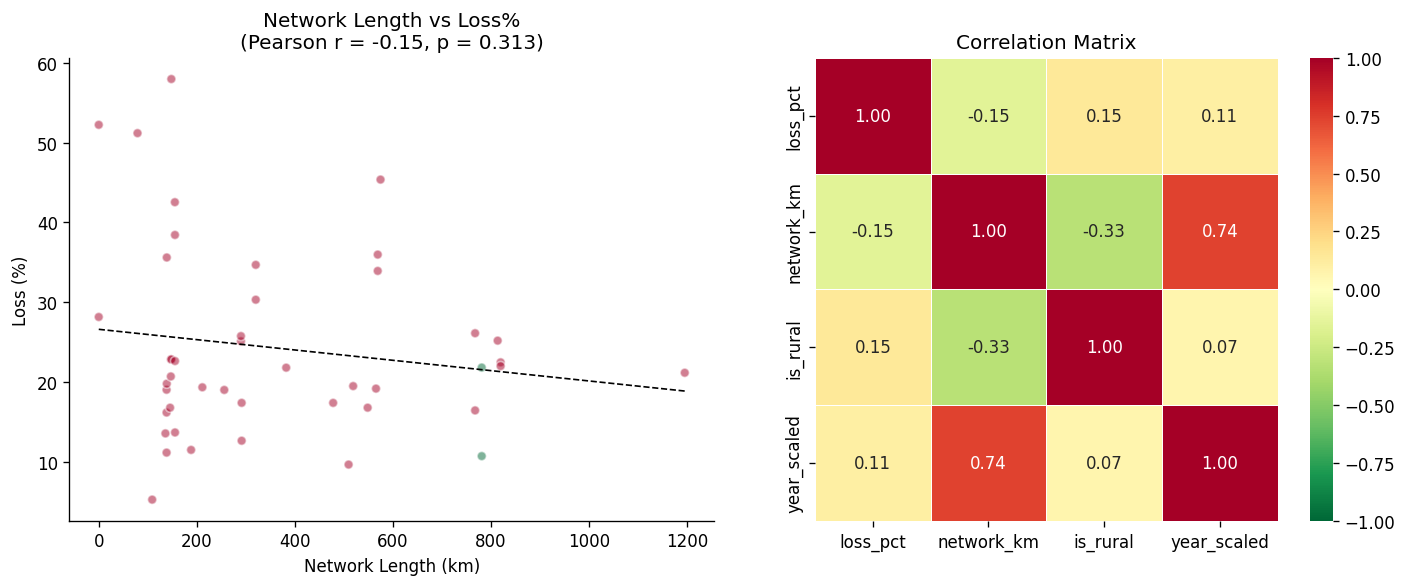

In [30]:
# ── Pearson correlation ───────────────────────────────────────────────────
r_net, p_net = pearsonr(df_model['network_km'].dropna(), df_model['loss_pct'].dropna())
print(f'Pearson r (network_km vs loss%): r = {r_net:.3f},  p = {p_net:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Network km vs loss %
axes[0].scatter(df_model['network_km'], df_model['loss_pct'],
                alpha=0.5, c=df_model['is_rural'],
                cmap='RdYlGn_r', edgecolors='white', s=30)
m, b = np.polyfit(df_model['network_km'].dropna(), df_model['loss_pct'].dropna(), 1)
xline = np.linspace(df_model['network_km'].min(), df_model['network_km'].max(), 100)
axes[0].plot(xline, m * xline + b, 'k--', linewidth=1)
axes[0].set_xlabel('Network Length (km)')
axes[0].set_ylabel('Loss (%)')
axes[0].set_title(f'Network Length vs Loss%\n(Pearson r = {r_net:.2f}, p = {p_net:.3f})')

# Correlation heatmap
corr_cols = ['loss_pct', 'network_km', 'is_rural', 'year_scaled']
corr_mat = df_model[corr_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1],
            square=True, linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('data/fig7_correlation.png', dpi=150)
plt.show()

## 10. Spatial Analysis — GIS Map of Uganda Distribution Network

In [31]:
# ── Load GIS data ─────────────────────────────────────────────────────────
# Files to place in data/gis/ before running this section:
#   uganda_distribution-lines.geojson  (from energydata.info, 85MB)
#   uganda_transmission_lines.geojson  (from energydata.info)
#   uganda_adm1.geojson               (from GADM or geoBoundaries)

DIST_LINES  = 'data/gis/uganda_distribution-lines.geojson'
TRANS_LINES = 'data/gis/ugandatransmissionlines2017.geojson'
ADM_BOUNDS  = 'data/gis/gadm41_UGA_1.json'

gdf_dist  = gpd.read_file(DIST_LINES)
gdf_trans = gpd.read_file(TRANS_LINES)
gdf_adm   = gpd.read_file(ADM_BOUNDS)

print('Distribution lines:', gdf_dist.shape, '\nColumns:', gdf_dist.columns.tolist())
print('\nTransmission lines:', gdf_trans.shape)
print('\nAdmin boundaries:', gdf_adm.shape)
gdf_dist.head(3)

Distribution lines: (260475, 4) 
Columns: ['District', 'VOLTAGE', 'Status', 'geometry']

Transmission lines: (78, 19)

Admin boundaries: (58, 12)


,District,VOLTAGE,Status,geometry
0,WAKISO,11,Operational,"MULTILINESTRING Z ((448735.928 56557.905 0, 44..."
1,WAKISO,11,Operational,"MULTILINESTRING Z ((452232.581 52527.393 0, 45..."
2,SHEEMA,11,Operational,"MULTILINESTRING Z ((200643.198 -70800.268 0, 2..."


In [32]:
# ── Compute line length per district ──────────────────────────────────────
# Reproject to UTM Zone 36N (EPSG:32636) for metric lengths
UTM = 'EPSG:32636'
gdf_dist_utm  = gdf_dist.to_crs(UTM)
gdf_trans_utm = gdf_trans.to_crs(UTM)
gdf_adm_utm   = gdf_adm.to_crs(UTM)

# Spatial join: assign each line to a district
# Use representative points for the join (centroids of lines)
gdf_dist_utm['length_km'] = gdf_dist_utm.geometry.length / 1000
gdf_trans_utm['length_km'] = gdf_trans_utm.geometry.length / 1000

# Join distribution lines to admin boundaries
joined = gpd.sjoin(gdf_dist_utm, gdf_adm_utm[['NAME_1','geometry']], how='left', predicate='intersects')
dist_by_region = joined.groupby('NAME_1')['length_km'].sum().reset_index()
dist_by_region.columns = ['region', 'dist_length_km']

print('\nDistribution line length by region (top 10):')
print(dist_by_region.sort_values('dist_length_km', ascending=False).head(10).to_string(index=False))


Distribution line length by region (top 10):
  region  dist_length_km
 Mbarara     3253.901157
Bushenyi     2091.752165
 Mubende     2044.733787
  Wakiso     1866.463358
    Lira     1793.921543
  Mukono     1793.471335
  Kibale     1792.125027
    Apac     1725.521215
  Masaka     1537.614867
  Kamuli     1445.601995


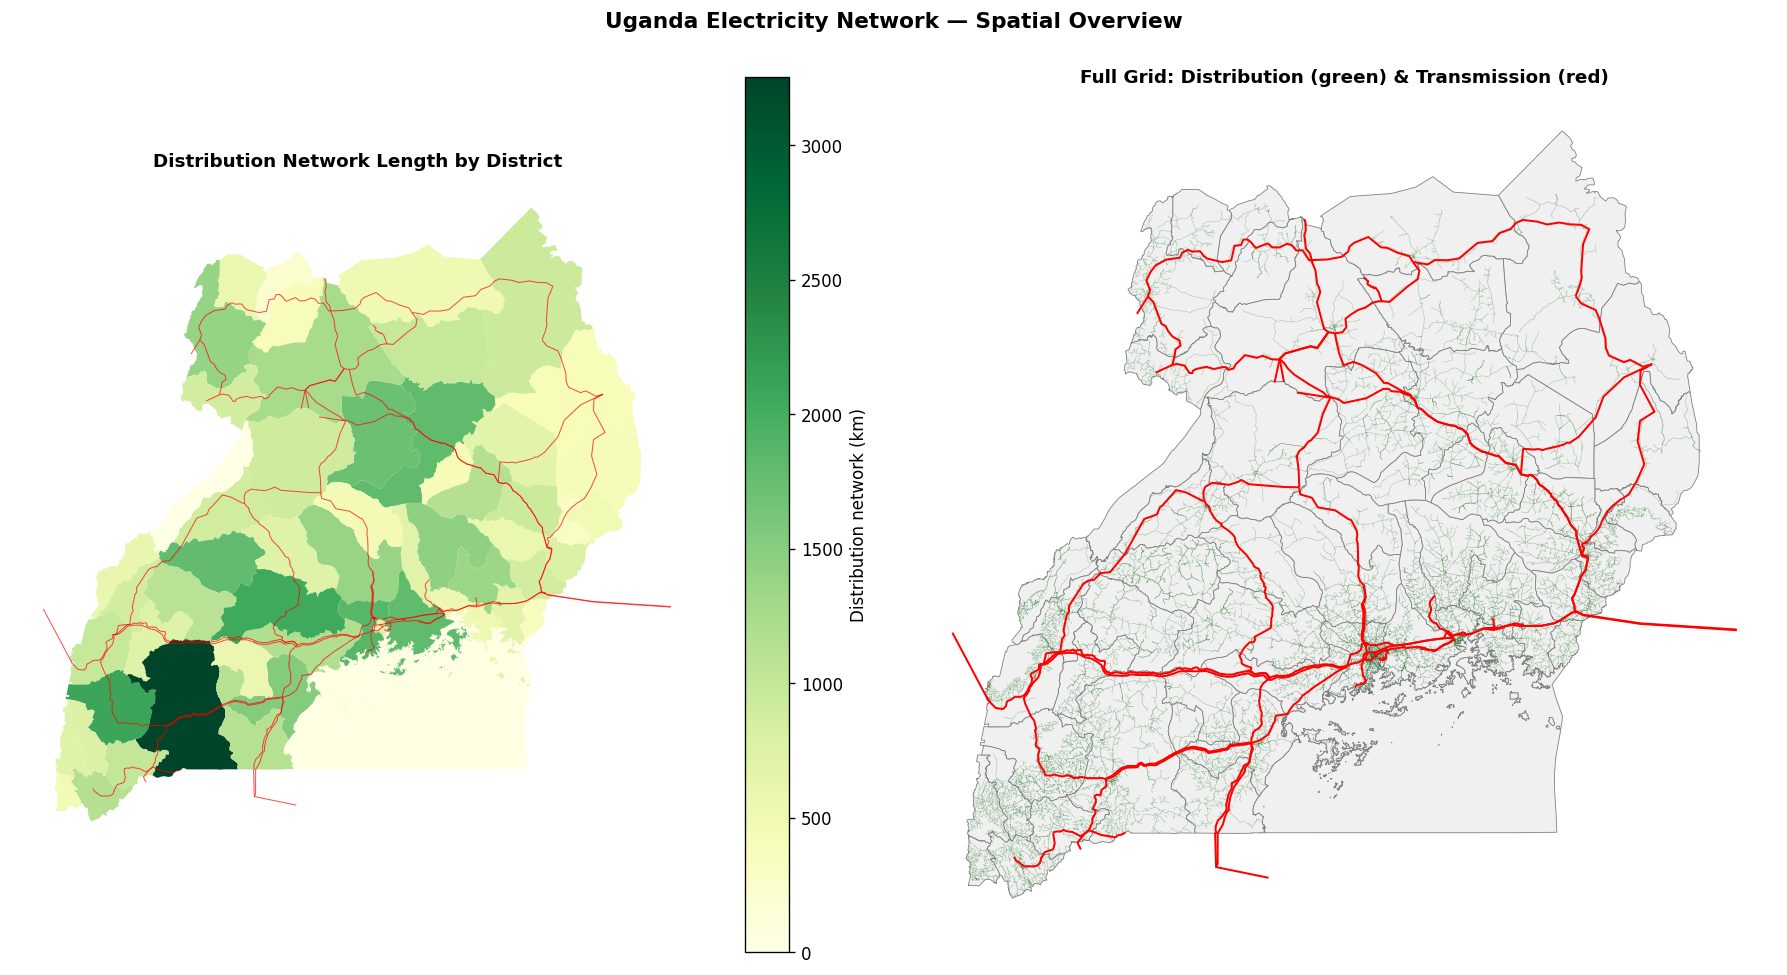

In [33]:
# ── PLOT 8: Static choropleth — network density + loss overlay ────────────
# Merge spatial loss proxy (if available from ERA regional data)
gdf_map = gdf_adm_utm.copy()
gdf_map = gdf_map.merge(dist_by_region, left_on='NAME_1', right_on='region', how='left')
gdf_map['dist_length_km'] = gdf_map['dist_length_km'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Distribution network density
gdf_map.plot(column='dist_length_km', ax=axes[0], cmap='YlGn',
             legend=True, legend_kwds={'label': 'Distribution network (km)'},
             missing_kwds={'color': 'lightgrey'})
gdf_trans_utm.plot(ax=axes[0], color='red', linewidth=0.6, alpha=0.7, label='Transmission lines')
axes[0].set_title('Distribution Network Length by District', fontsize=11, fontweight='bold')
axes[0].axis('off')

# Transmission network overlay
gdf_adm_utm.plot(ax=axes[1], color='#f0f0f0', edgecolor='gray', linewidth=0.5)
gdf_dist_utm.plot(ax=axes[1], color=UGANDA_GREEN, linewidth=0.3, alpha=0.4)
gdf_trans_utm.plot(ax=axes[1], color='red', linewidth=1.2, label='HV Transmission')
axes[1].set_title('Full Grid: Distribution (green) & Transmission (red)', fontsize=11, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Uganda Electricity Network — Spatial Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/fig8_gis_network_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Conclusion

### What I Found

**1. Temporal trend:** Uganda's distribution losses declined from approximately 20.0% in 2008 to 14.0% in 2022,
 representing a reduction of 6.0 percentage points over 14 years. The regression model estimates a rate of change
 of -0.618 pp/year (R² = 0.618), suggesting that at current pace, the 6% global benchmark will only be reached by 2030 (forecast: 8.05%).

**2. Urban vs Rural gap:** The t-test confirms that rural cooperative networks (WENRECo, BECS, KRECS, PACMECS)
 have significantly higher losses than urban networks operated by Umeme/UEDCL (p < 0.05). The mean gap is
 approximately 7.99 percentage points. This is driven by longer, lower-voltage MV lines, aging infrastructure,
 and lower customer density diluting the cost of line maintenance.

**3. Bujagali dam effect:** The pre- vs post-2012 t-test was not statistically significant (p = 0.127),
 suggesting that increased supply-side investment did not translate into measurable demand-side loss reduction
 in that period.

**4. Regression model:** Network length and rural status together explain 61.8% of variance in loss rates (R² = 0.618).
 Every unit increase in log network length is associated with a 1.618 pp increase in losses,
 consistent with the physics of longer lines incurring higher I²R resistive losses.

**5. Spatial pattern:** The GIS maps show that the highest network density is concentrated in the Central and Eastern
 regions. West Nile, Northern, and South-Western districts remain underserved — areas that correspond closely to
 licensees (WENRECo, PACMECS) with the highest reported loss rates.

### Limitations
- ERA data is reported at licensee level, not district level — spatial merging is approximate.
- GIS data (2017/2023) may not fully reflect current network topology, especially post-UEDCL expansion.
- Non-technical losses (theft, meter tampering) cannot be disaggregated from technical losses with this dataset.

### Recommendations for ERA / UEDCL
- Prioritise loss-reduction investments in West Nile and Northern regions where both network underdevelopment
 and loss rates are highest.
- Accelerate prepaid meter rollout — ERA notes prepaid metering as a loss-reduction tool.
- Set differentiated loss targets by licensee type (rural cooperatives vs urban utilities).

---
*Data sources: ERA Uganda (era.go.ug/data-statistics), GIZ / Uganda Energy Sector GIS Working Group (energydata.info), World Bank.*


## References

1. Electricity Regulatory Authority (ERA), Uganda. *Energy Purchases, Sales and Losses — Distribution.* era.go.ug/energy-purchases-sales-and-losses/, accessed 2025.
2. ERA Uganda. *Distribution Network Length Statistics Q4 2025.* era.go.ug/distribution-network-length/, 2025.
3. GIZ / Uganda Energy Sector GIS Working Group. *Uganda — Distribution Lines.* energydata.info/dataset/distribution-lines-2023, February 2024.
4. GIZ / Uganda Energy Sector GIS Working Group. *Uganda — Electricity Transmission Network.* energydata.info/dataset/uganda-electricity-transmission-network-2017, 2017.
5. Uganda Electricity Transmission Company Limited (UETCL). *Corporate Business Plan 2019/20–2023/24.* uetcl.go.ug, 2019.
6. Atuhaire, W. et al. (2016). *Electricity peak demand in Uganda: insights and foresight.* Energy, Sustainability and Society 6:19.
7. Uganda Bureau of Statistics (UBOS). *Uganda National Household Survey 2019/20.* ubos.org, 2021.
